In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [6]:
TIME_STEP = 15                  # 15-day sequences 
EPOCHS = 200
BATCH_SIZE = 32
MODE = "univariate"
# Helper 
def create_sequences(X_array, y_array, time_step=15):
    Xs, ys = [], []
    for i in range(time_step, len(X_array)):
        Xs.append(X_array[i-time_step:i])
        ys.append(y_array[i])  
    return np.array(Xs), np.array(ys)

In [7]:
df = pd.read_csv("BTC_USD_data.csv")
print("Loaded data shape:", df.shape)
print("Columns:", list(df.columns))

Loaded data shape: (4093, 14)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']


In [8]:
# Preprocessing 
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")
# Sort data chronologically
df = df.sort_values("Date").reset_index(drop=True)
# Handle missing values if any
# Step A: remove rows with missing Date (invalid dates)
df = df.dropna(subset=["Date"]).reset_index(drop=True)
# Step B: numeric columns - coerce to numeric then fill missing
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
# Fill missing values:
# - Prices: forward fill then backfill (time series friendly)
# - Volume: forward fill then backfill
df[numeric_cols] = df[numeric_cols].ffill().bfill()
# Basic sanity: remove impossible rows (optional, but safe)
# High should be >= Low, and prices should be > 0
df = df[(df["High"] >= df["Low"]) & (df["Close"] > 0)].reset_index(drop=True)
print("\nAfter preprocessing, shape:", df.shape)
print("Missing values per column:\n", df.isna().sum())


After preprocessing, shape: (2485, 14)
Missing values per column:
 Date              0
Open              0
High              0
Low               0
Close             0
Adj Close         0
Volume            0
Unnamed: 7     2485
Unnamed: 8     2485
Unnamed: 9     2485
Unnamed: 10    2485
Unnamed: 11    2485
Unnamed: 12    2485
Unnamed: 13    2484
dtype: int64


In [9]:
# Lag features (previous day prices)
df["Close_lag1"] = df["Close"].shift(1)
# Rolling averages (7-day, 30-day)
df["Close_MA7"] = df["Close"].rolling(window=7).mean()
df["Close_MA30"] = df["Close"].rolling(window=30).mean()
# Price change percentage
df["Close_pct_change"] = df["Close"].pct_change() * 100.0
# Volatility measures (High-Low range)
df["HL_range"] = df["High"] - df["Low"]
df["HL_pct"] = (df["High"] - df["Low"]) / df["Close"] * 100.0
# Volume-based indicators
df["Volume_MA7"] = df["Volume"].rolling(window=7).mean()
df["Volume_pct_change"] = df["Volume"].pct_change() * 100.0
# After creating rolling/lag features, the first few rows become NaN -> fill
engineered_cols = ["Close_lag1", "Close_MA7", "Close_MA30",
                   "Close_pct_change", "HL_range", "HL_pct",
                   "Volume_MA7", "Volume_pct_change"]
df[engineered_cols] = df[engineered_cols].ffill().bfill()


EDA: plotting... (close the plot windows to continue)



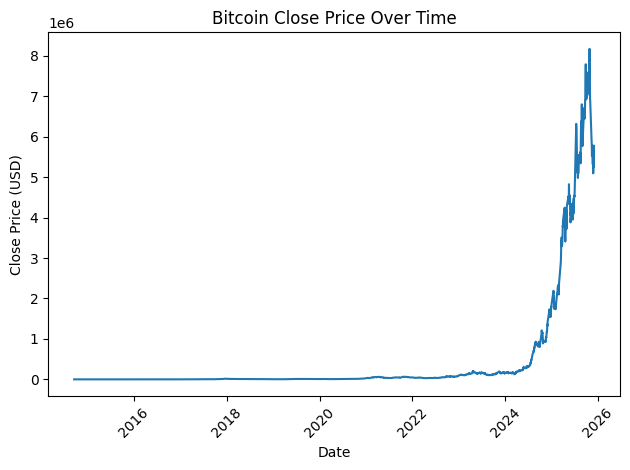

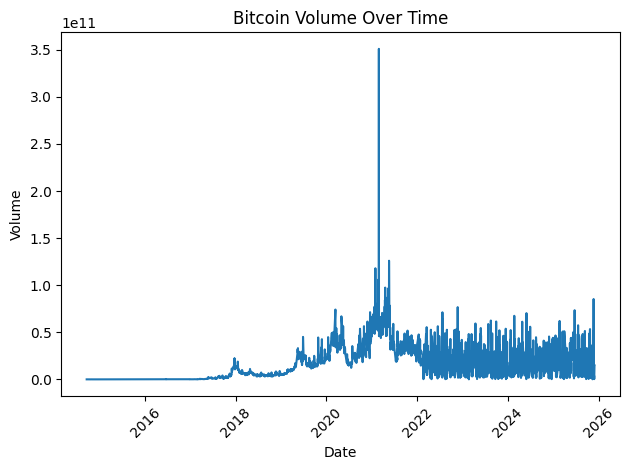

In [10]:
# EDA 
print("\nEDA: plotting... (close the plot windows to continue)\n")
# Volume vs price trend analysis
plt.figure()
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure()
plt.plot(df["Date"], df["Volume"])
plt.title("Bitcoin Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

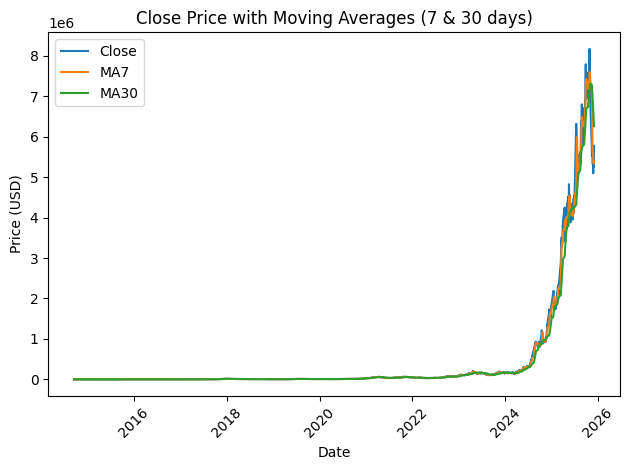

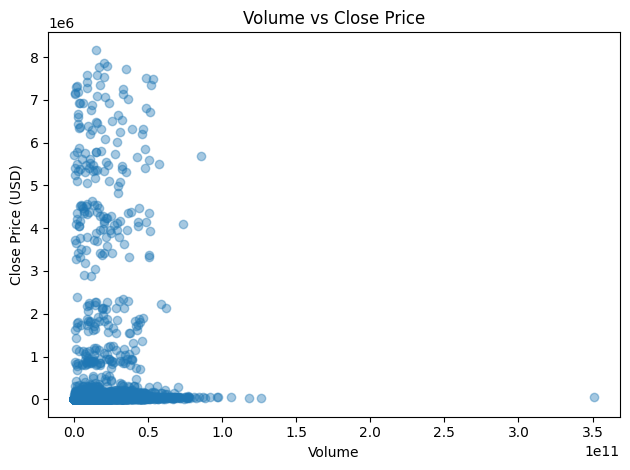

In [11]:
# Moving average visualization
plt.figure()
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["Close_MA7"], label="MA7")
plt.plot(df["Date"], df["Close_MA30"], label="MA30")
plt.title("Close Price with Moving Averages (7 & 30 days)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure()
plt.scatter(df["Volume"], df["Close"], alpha=0.4)
plt.title("Volume vs Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price (USD)")
plt.tight_layout()
plt.show()

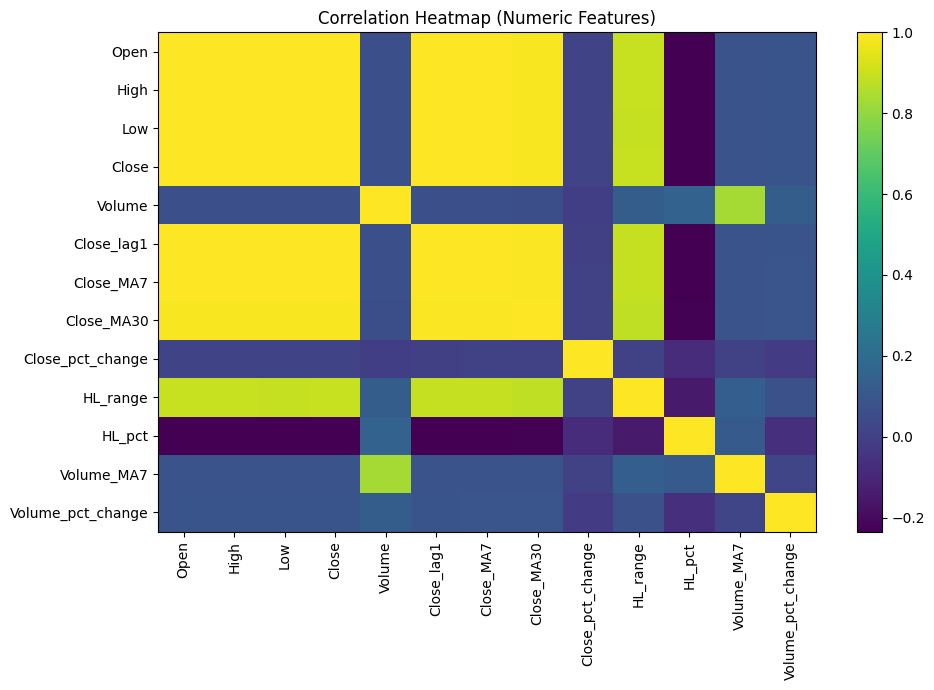

In [12]:
# Correlation heatmap of numeric features 
corr_cols = ["Open","High","Low","Close","Volume",
             "Close_lag1","Close_MA7","Close_MA30",
             "Close_pct_change","HL_range","HL_pct",
             "Volume_MA7","Volume_pct_change"]
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

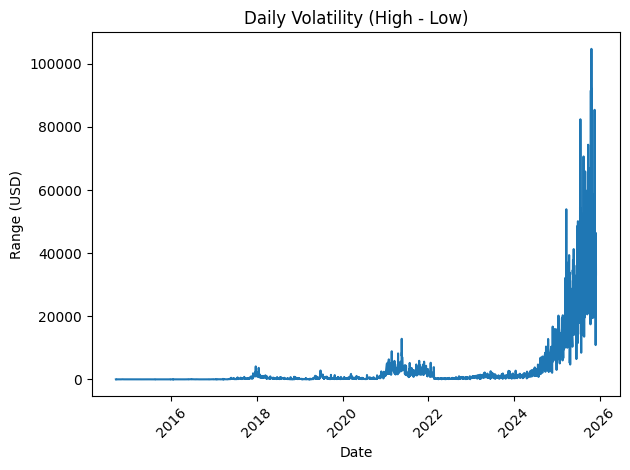

In [13]:
# Volatility analysis (High-Low range)
plt.figure()
plt.plot(df["Date"], df["HL_range"])
plt.title("Daily Volatility (High - Low)")
plt.xlabel("Date")
plt.ylabel("Range (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Monthly and yearly analyses of Open/Close/High/Low for each year
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

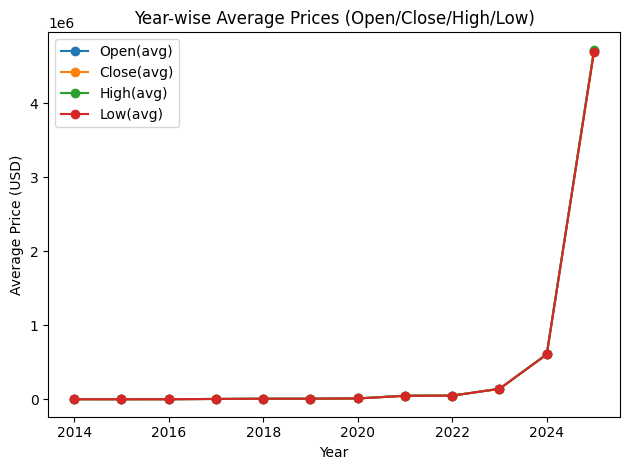

In [15]:
# Yearly average prices (line plot)
yearly = df.groupby("Year")[["Open","Close","High","Low"]].mean()
plt.figure()
plt.plot(yearly.index, yearly["Open"], marker="o", label="Open(avg)")
plt.plot(yearly.index, yearly["Close"], marker="o", label="Close(avg)")
plt.plot(yearly.index, yearly["High"], marker="o", label="High(avg)")
plt.plot(yearly.index, yearly["Low"], marker="o", label="Low(avg)")
plt.title("Year-wise Average Prices (Open/Close/High/Low)")
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

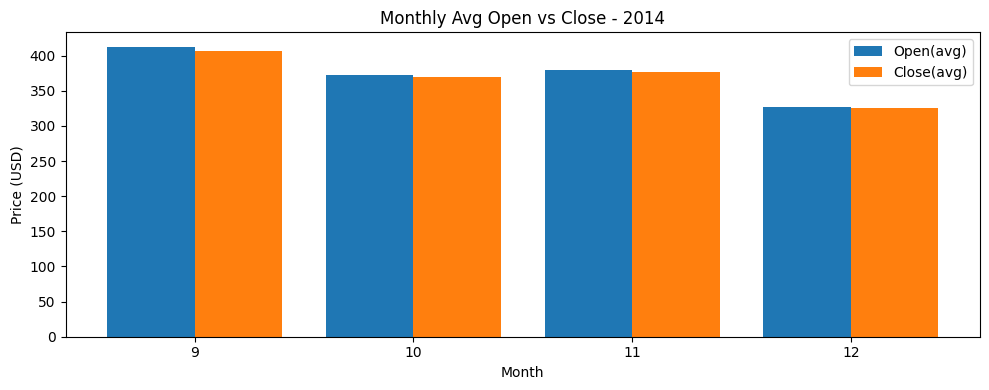

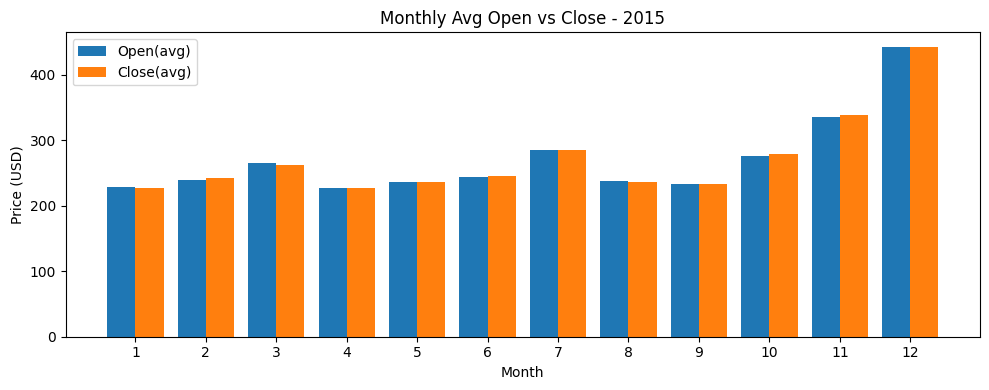

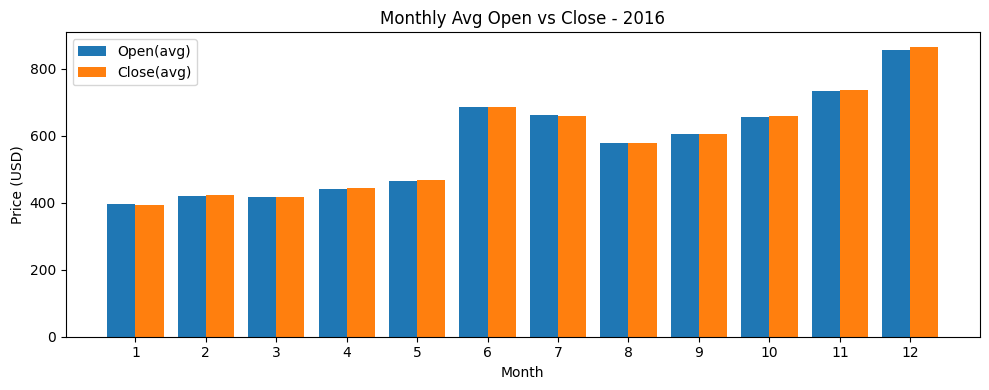

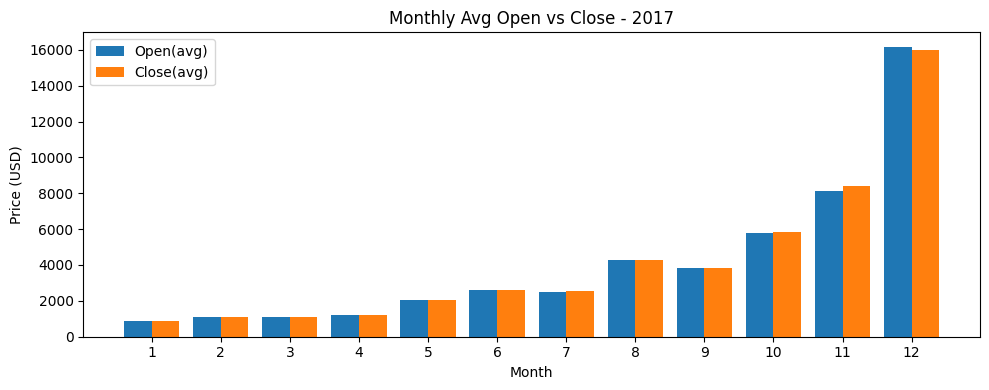

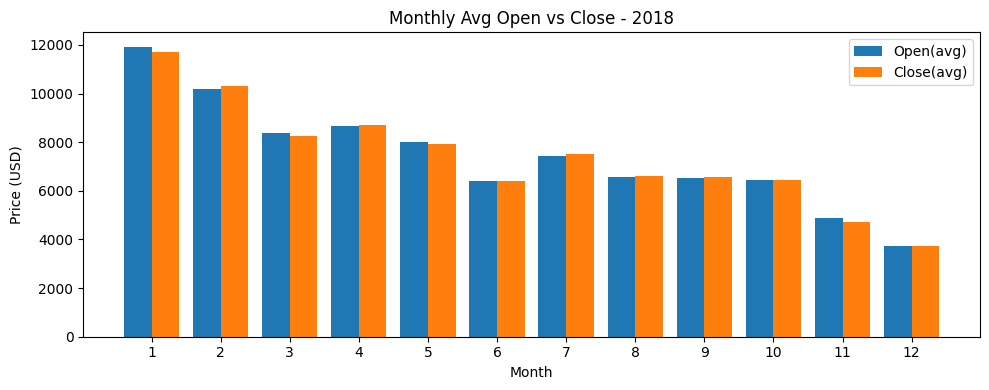

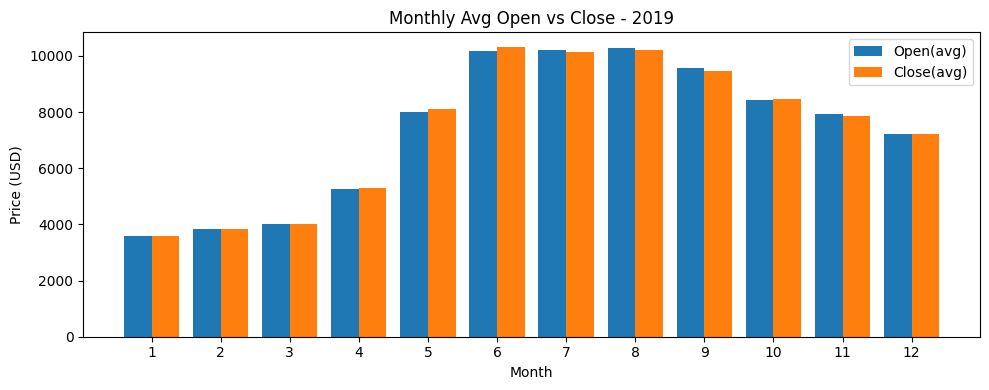

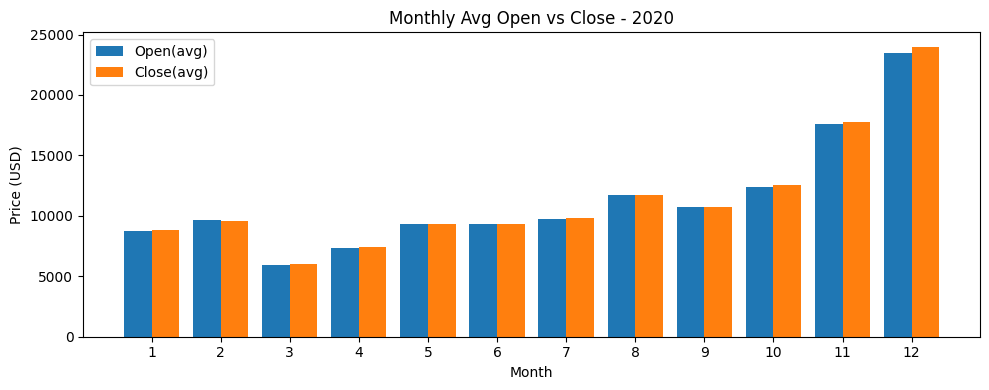

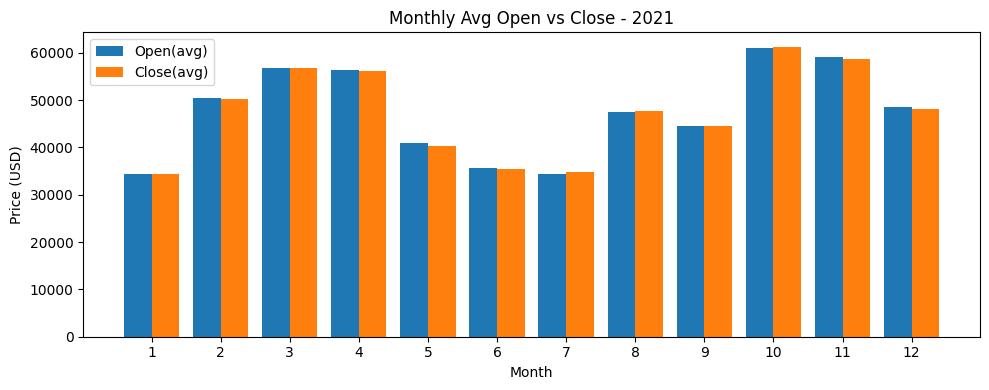

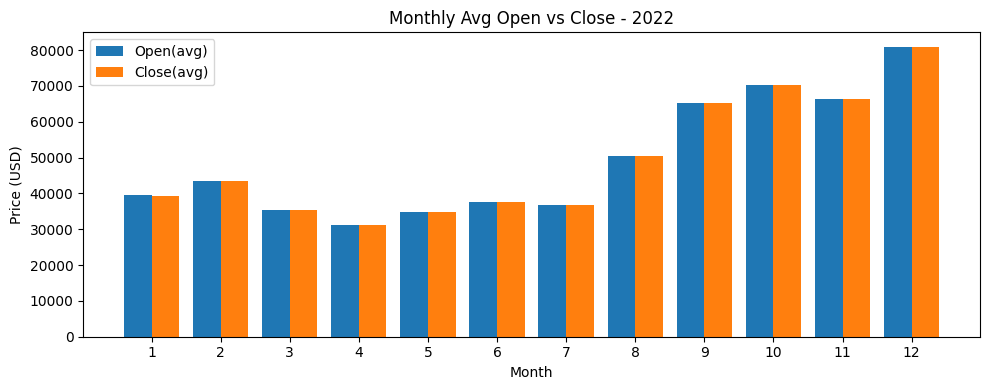

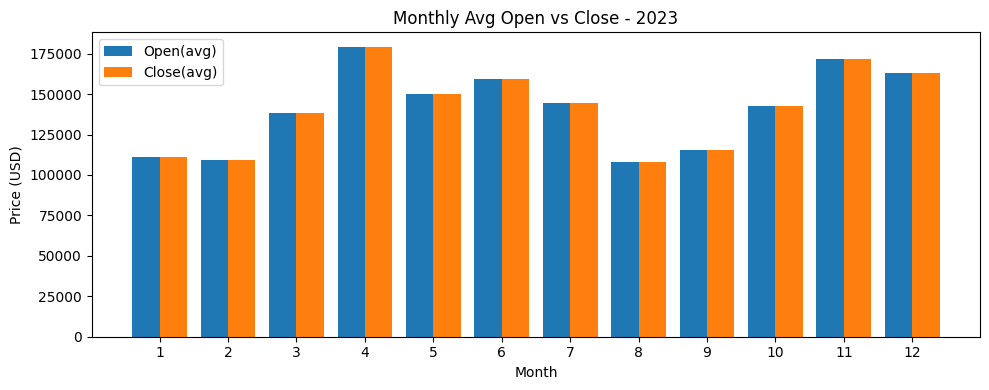

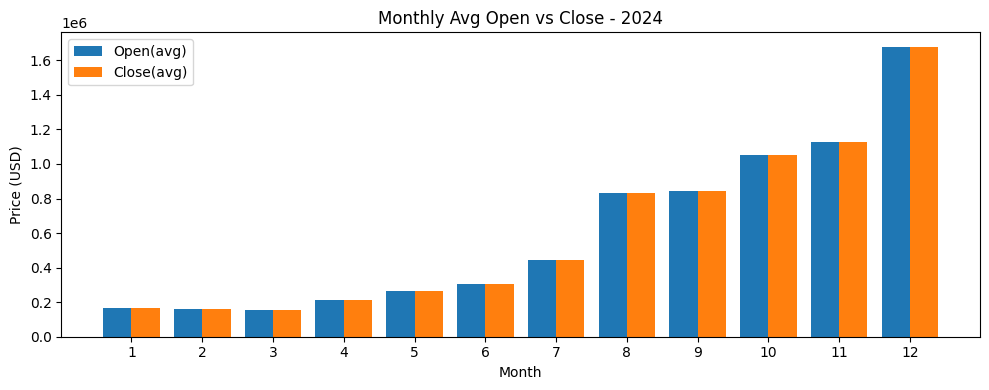

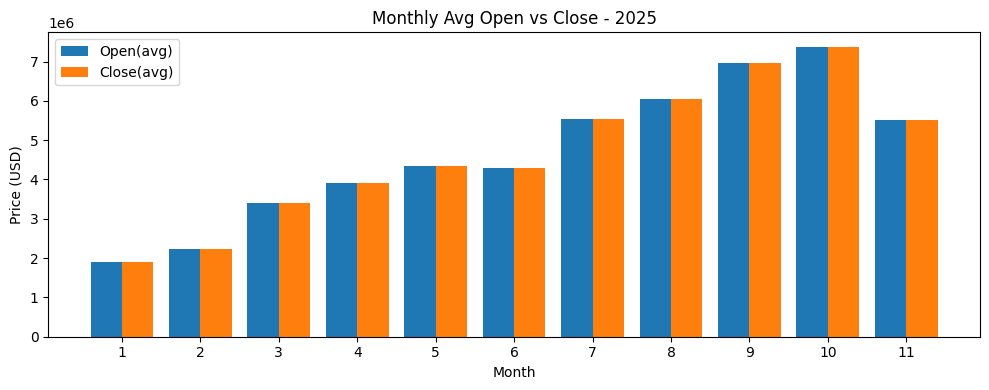

In [16]:
# Monthly open vs close comparisons for each year (bar chart)
years = sorted(df["Year"].unique())
for y in years:
    temp = df[df["Year"] == y].groupby("Month")[["Open","Close"]].mean()
    if temp.shape[0] == 0:
        continue
    plt.figure(figsize=(10, 4))
    x = np.arange(len(temp.index))
    width = 0.4
    plt.bar(x - width/2, temp["Open"].values, width=width, label="Open(avg)")
    plt.bar(x + width/2, temp["Close"].values, width=width, label="Close(avg)")
    plt.title(f"Monthly Avg Open vs Close - {y}")
    plt.xlabel("Month")
    plt.ylabel("Price (USD)")
    plt.xticks(x, temp.index)
    plt.legend()
    plt.tight_layout()
    plt.show()



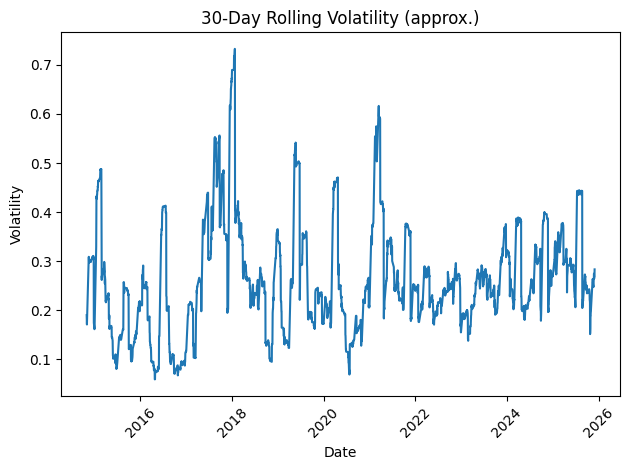

In [17]:
# Detect seasonality / volatility spikes 
df["Close_return"] = df["Close"].pct_change()
df["Volatility_30"] = df["Close_return"].rolling(30).std() * np.sqrt(30)
plt.figure()
plt.plot(df["Date"], df["Volatility_30"])
plt.title("30-Day Rolling Volatility (approx.)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [18]:
#Prepare data for LSTM
# Target: Close price (next day)
if MODE.lower() == "univariate":
    feature_cols = ["Close"]
else:
    feature_cols = ["Open","High","Low","Close","Volume",
                    "Close_lag1","Close_MA7","Close_MA30",
                    "Close_pct_change","HL_range","HL_pct",
                    "Volume_MA7","Volume_pct_change"]
print("\nMODE:", MODE)
print("Using features:", feature_cols)
X_raw = df[feature_cols].values.astype(float)
y_raw = df["Close"].values.astype(float).reshape(-1, 1)
# Normalize using Min-Max scaling
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)


MODE: univariate
Using features: ['Close']


In [19]:
# Train-test split (chronological)
split_index = int(len(df) * 0.80)
X_train_raw = X_scaled[:split_index]
X_test_raw = X_scaled[split_index:]
y_train_raw = y_scaled[:split_index]
y_test_raw = y_scaled[split_index:]
# Create sequences (15 days)
X_train, y_train = create_sequences(X_train_raw, y_train_raw, TIME_STEP)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, TIME_STEP)
print("\nSequence shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)



Sequence shapes:
X_train: (1973, 15, 1) y_train: (1973, 1)
X_test : (482, 15, 1) y_test : (482, 1)


In [20]:
# Build & train LSTM 
tf.random.set_seed(42)
np.random.seed(42)
model = Sequential()
model.add(LSTM(10, activation="relu", input_shape=(TIME_STEP, X_train.shape[2])))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10)                  │             480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.1496e-05 - val_loss: 0.2479
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7360e-05 - val_loss: 0.2372
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4823e-05 - val_loss: 0.2167
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1075e-05 - val_loss: 0.1781
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4420e-06 - val_loss: 0.1133
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7013e-06 - val_loss: 0.0475
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1319e-07 - val_loss: 0.0299
Epoch 8/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6952e-07 - val_loss: 0.0302
Epoch 9/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7793e-07 - val_loss: 0.0302
Epoch 10/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8151e-07 - val_loss: 0.0296
Epoch 11/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7857e-07 - val_loss: 0.0291
Epoch 12/200
62/62 

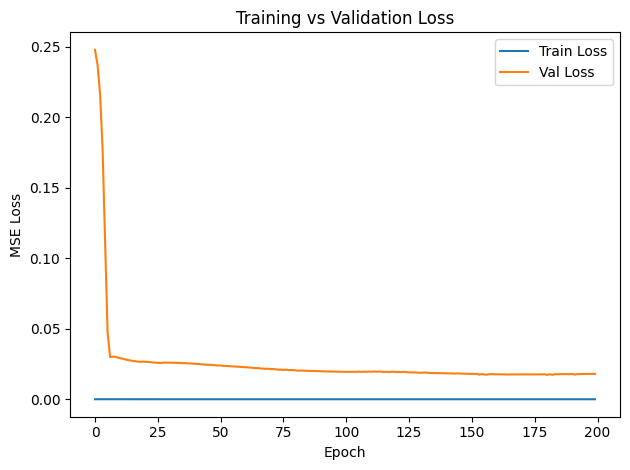

In [21]:
# Plot training curve
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Predictions (train/test) + plots
train_pred_scaled = model.predict(X_train)
test_pred_scaled = model.predict(X_test)
train_pred = scaler_y.inverse_transform(train_pred_scaled)
test_pred = scaler_y.inverse_transform(test_pred_scaled)



62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


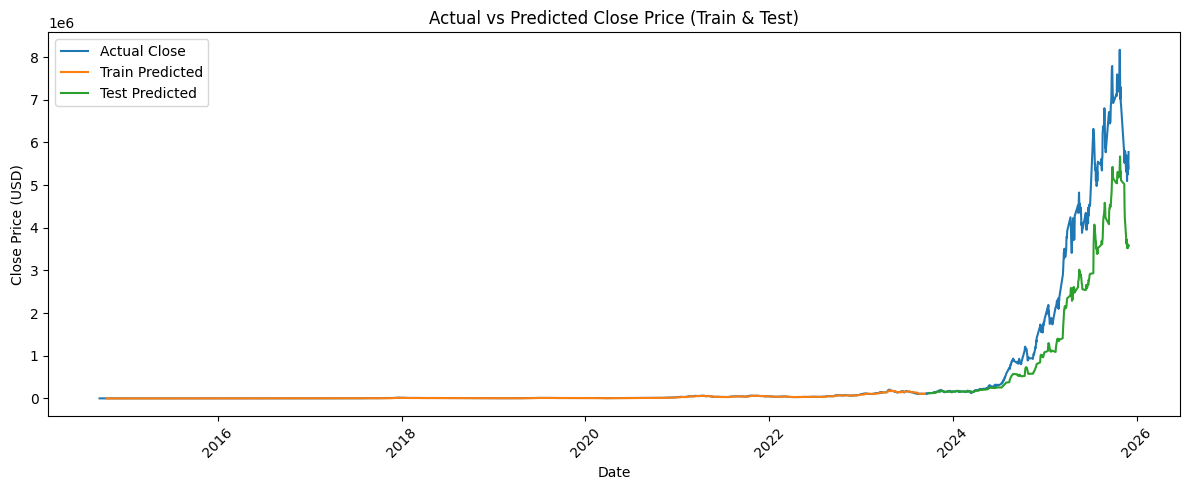

In [23]:
# Build aligned arrays for plotting
train_plot = np.empty((split_index, 1))
train_plot[:] = np.nan
train_plot[TIME_STEP:] = train_pred
test_plot = np.empty((len(df) - split_index, 1))
test_plot[:] = np.nan
test_plot[TIME_STEP:] = test_pred
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"], label="Actual Close")
plt.plot(df["Date"][:split_index], train_plot, label="Train Predicted")
plt.plot(df["Date"][split_index:], test_plot, label="Test Predicted")
plt.title("Actual vs Predicted Close Price (Train & Test)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [24]:
# Future Forecast (Next 30 days) - iterative multi-step
print("\nForecasting next 30 days (iterative multi-step)...")
# For a realistic 30-day forecast, we use close-only data (univariate) because future OHLCV is unknown.
close_series = df["Close"].values.reshape(-1, 1)
close_scaler = MinMaxScaler((0, 1))
close_scaled = close_scaler.fit_transform(close_series)
# If MODE is univariate, we can reuse the trained model (same architecture).
# If MODE is multivariate, we train a small close-only model for forecasting.
if MODE.lower() == "univariate":
    forecast_model = model
else:
    Xc, yc = create_sequences(close_scaled, close_scaled, TIME_STEP)
    split_c = int(len(Xc) * 0.80)
    Xc_train, yc_train = Xc[:split_c], yc[:split_c]
    Xc_test, yc_test = Xc[split_c:], yc[split_c:]
    forecast_model = Sequential()
    forecast_model.add(LSTM(10, activation="relu", input_shape=(TIME_STEP, 1)))
    forecast_model.add(Dense(1))
    forecast_model.compile(loss="mean_squared_error", optimizer="adam")
    forecast_model.fit(Xc_train, yc_train, validation_data=(Xc_test, yc_test),
                       epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)


Forecasting next 30 days (iterative multi-step)...


In [27]:
# Start from last 15 days
last_window = close_scaled[-TIME_STEP:].reshape(1, TIME_STEP, 1)
future_scaled = []
for _ in range(30):
    next_scaled = forecast_model.predict(last_window, verbose=0)[0][0]
    future_scaled.append(next_scaled)
    # Slide the window (drop first, append new prediction)
    new_window = np.append(last_window.flatten()[1:], next_scaled)
    last_window = new_window.reshape(1, TIME_STEP, 1)
future_scaled = np.array(future_scaled).reshape(-1, 1)
future_prices = close_scaler.inverse_transform(future_scaled).flatten()

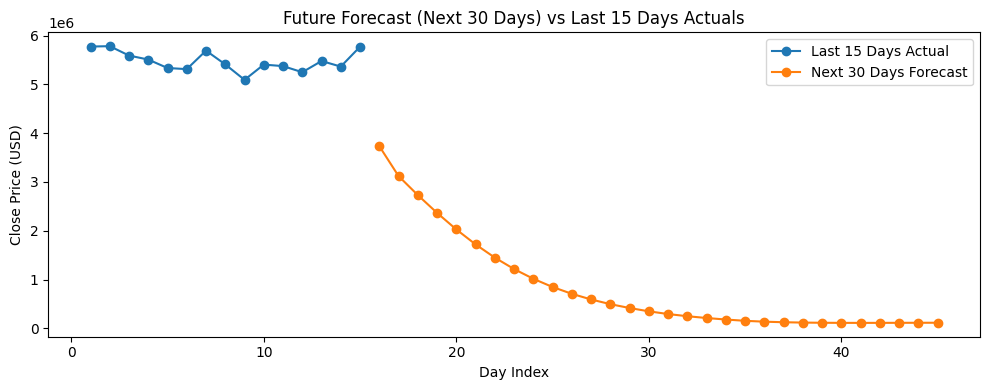


Next 30 forecasted closing prices (USD) - first 10 shown:
[3734917.   3121410.   2731343.2  2366357.2  2027044.6  1720357.
 1448967.6  1214560.9  1015047.06  846693.8 ]


In [28]:
# Plot Future Forecast vs Last 15 Actual
last_15_actual = df["Close"].values[-TIME_STEP:]
plt.figure(figsize=(10, 4))
plt.plot(range(1, TIME_STEP+1), last_15_actual, marker="o", label="Last 15 Days Actual")
plt.plot(range(TIME_STEP+1, TIME_STEP+31), future_prices, marker="o", label="Next 30 Days Forecast")
plt.title("Future Forecast (Next 30 Days) vs Last 15 Days Actuals")
plt.xlabel("Day Index")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()
print("\nNext 30 forecasted closing prices (USD) - first 10 shown:")
print(np.round(future_prices[:10], 2))

In [32]:
# Sample prediction component (next-day close)
print("\nSAMPLE PREDICTION:")
print("Provide last 15 days Close values to predict the next-day Close.\n")
sample_close_15days = last_15_actual.tolist()  # example
sample_scaled = close_scaler.transform(np.array(sample_close_15days).reshape(-1, 1))
sample_X = sample_scaled.reshape(1, TIME_STEP, 1)
next_day_scaled = forecast_model.predict(sample_X, verbose=0)
next_day_price = close_scaler.inverse_transform(next_day_scaled)[0][0]
print("Predicted next-day closing price (USD):",round(float(next_day_price), 2))


SAMPLE PREDICTION:
Provide last 15 days Close values to predict the next-day Close.

Predicted next-day closing price (USD): 3734917.0
